In [ ]:

# Predictive Model (Linear Regression & Random Forest)
# Import Machine Learning Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,r2_score)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("listings.csv")
df.tail()

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,instant_bookable,is_business_travel_ready,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
85063,39868875,https://www.airbnb.com/rooms/39868875,20191105115249,2019-11-06,"The Apartment, East London Village","Cool, quiet and perfectly located London apart...",Lovely apartment with 1 large bedroom with que...,"Cool, quiet and perfectly located London apart...",none,It’s got enough community spirit to make you s...,...,t,f,strict_14_with_grace_period,f,f,1,1,0,0,NaN
85064,39869123,https://www.airbnb.com/rooms/39869123,20191105115249,2019-11-06,Elegant stylish modern house with amazing view!,Elegant stylish house with amazing view in nic...,NaN,Elegant stylish house with amazing view in nic...,none,NaN,...,f,f,flexible,f,f,2,0,2,0,NaN
85065,39869214,https://www.airbnb.com/rooms/39869214,20191105115249,2019-11-06,Holland Road - Kensington Olympia,"Perfectly located apartment, Excellent stay fo...","Cozy modern apartment , wooden floor throughou...","Perfectly located apartment, Excellent stay fo...",none,The affluent area of Kensington is home to man...,...,t,f,strict_14_with_grace_period,f,f,4,4,0,0,NaN
85066,39869249,https://www.airbnb.com/rooms/39869249,20191105115249,2019-11-06,Functional single room 18 min to London Bridge,"An inviting, modern, cosy single room with spa...",The property is conveniently located opposite ...,"An inviting, modern, cosy single room with spa...",none,Chelsfield has its own local parade of shops a...,...,t,f,flexible,f,f,4,1,3,0,NaN
85067,39869282,https://www.airbnb.com/rooms/39869282,20191105115249,2019-11-06,"EXQUISITE APARTMENT, PEACEFUL ENVIRONMENT IN SOHO","Amazing location, simply could not be any bett...",NaN,"Amazing location, simply could not be any bett...",none,"Really central, Leicester Square, and Covent G...",...,t,f,flexible,f,f,1,1,0,0,NaN


In [ ]:
df.head()

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,instant_bookable,is_business_travel_ready,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,11551,https://www.airbnb.com/rooms/11551,20191105115249,2019-11-06,Arty and Bright London Apartment in Zone 2,Unlike most rental apartments out there my fla...,"Amenities Bedding: 1 Double bed, 1 living room...",Unlike most rental apartments out there my fla...,family,Not even 10 minutes by metro from Victoria Sta...,...,t,f,strict_14_with_grace_period,f,t,2,2,0,0,1.58
1,38151,https://www.airbnb.com/rooms/38151,20191105115249,2019-11-06,Double room/ lounge,NaN,"Comfortable, large double room /lounge area av...","Comfortable, large double room /lounge area av...",none,NaN,...,f,f,flexible,f,f,1,0,1,0,NaN
2,13913,https://www.airbnb.com/rooms/13913,20191105115249,2019-11-06,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,"Hello Everyone, I'm offering my lovely double ...",My bright double bedroom with a large window h...,business,Finsbury Park is a friendly melting pot commun...,...,f,f,moderate,f,f,2,1,1,0,0.17
3,38407,https://www.airbnb.com/rooms/38407,20191105115249,2019-11-06,Canary Wharf Immaculate Apt for 2,"The bright, light and stylish apartment in Can...","An entire bright, light and stylish apartment....","The bright, light and stylish apartment in Can...",none,Very easy to get to all the main sites. The tu...,...,t,f,strict_14_with_grace_period,f,f,1,1,0,0,1.23
4,90700,https://www.airbnb.com/rooms/90700,20191105115249,2019-11-06,Sunny Notting Hill flat & terrace,This is a home not a hotel - for the cost gues...,This charming 1 bedroom with en-suite bathroom...,This is a home not a hotel - for the cost gues...,none,A quick guide or a run through about the area ...,...,t,f,strict_14_with_grace_period,f,f,2,2,0,0,3.33


In [ ]:
df.shape  #Check Dataset Shape

(85068, 106)

In [ ]:
# Display Column Names
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary',
       'space', 'description', 'experiences_offered', 'neighborhood_overview',
       ...
       'instant_bookable', 'is_business_travel_ready', 'cancellation_policy',
       'require_guest_profile_picture', 'require_guest_phone_verification',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms', 'reviews_per_month'],
      dtype='object', length=106)

In [ ]:
df.info()   # To Check Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85068 entries, 0 to 85067
Columns: 106 entries, id to reviews_per_month
dtypes: float64(23), int64(21), object(62)
memory usage: 68.8+ MB


In [ ]:
df.describe() #Statistical Summary

,id,scrape_id,thumbnail_url,medium_url,xl_picture_url,host_id,host_acceptance_rate,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,8.506800e+04,8.506800e+04,0.0,0.0,0.0,8.506800e+04,0.0,85056.000000,85056.000000,0.0,...,63407.000000,63345.000000,63401.000000,63347.000000,63346.000000,85068.000000,85068.000000,85068.000000,85068.000000,65062.000000
mean,2.319997e+07,2.019111e+13,NaN,NaN,NaN,8.514442e+07,NaN,27.449786,27.449786,NaN,...,9.269150,9.623680,9.649154,9.538289,9.267057,22.151150,19.372972,2.056331,0.047821,1.201995
std,1.132475e+07,2.841814e+01,NaN,NaN,NaN,8.603532e+07,NaN,143.354443,143.354443,NaN,...,1.136704,0.901635,0.900786,0.820674,1.041420,110.654631,109.709751,9.303232,0.707090,1.402728
min,1.155100e+04,2.019111e+13,NaN,NaN,NaN,2.697000e+03,NaN,0.000000,0.000000,NaN,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,1.441315e+07,2.019111e+13,NaN,NaN,NaN,1.529856e+07,NaN,1.000000,1.000000,NaN,...,9.000000,10.000000,10.000000,9.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.250000
50%,2.363201e+07,2.019111e+13,NaN,NaN,NaN,4.762387e+07,NaN,2.000000,2.000000,NaN,...,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,1.000000,1.000000,0.000000,0.730000
75%,3.349281e+07,2.019111e+13,NaN,NaN,NaN,1.415435e+08,NaN,5.000000,5.000000,NaN,...,10.000000,10.000000,10.000000,10.000000,10.000000,5.000000,2.000000,1.000000,0.000000,1.630000
max,3.988030e+07,2.019111e+13,NaN,NaN,NaN,3.070013e+08,NaN,1270.000000,1270.000000,NaN,...,10.000000,10.000000,10.000000,10.000000,10.000000,999.000000,996.000000,164.000000,19.000000,20.130000


In [ ]:
# Check Missing Values
df.isnull().sum()


,0
id,0
listing_url,0
scrape_id,0
last_scraped,0
name,26
...,...
calculated_host_listings_count,0
calculated_host_listings_count_entire_homes,0
calculated_host_listings_count_private_rooms,0
calculated_host_listings_count_shared_rooms,0


In [ ]:
# Missing Percentage
missing = (df.isnull().sum() / len(df)) * 100
missing.sort_values(ascending=False)

,0
thumbnail_url,100.0
medium_url,100.0
host_acceptance_rate,100.0
xl_picture_url,100.0
neighbourhood_group_cleansed,100.0
...,...
require_guest_profile_picture,0.0
calculated_host_listings_count,0.0
calculated_host_listings_count_entire_homes,0.0
calculated_host_listings_count_private_rooms,0.0


In [ ]:
# Remove Unnecessary Columns and Fill Missing Values
df = df.loc[:, df.isnull().mean() < 0.5]

# For numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

# For categorical columns
categorical_columns = df.select_dtypes(include="object").columns
df[categorical_columns] = df[categorical_columns].fillna("Unknown")

# Remove Duplicates
df = df.drop_duplicates()
# Check Duplicate Rows
df.duplicated().sum()


np.int64(0)

In [ ]:
# Check Data Types
df.dtypes

,0
id,int64
listing_url,object
scrape_id,int64
last_scraped,object
name,object
...,...
calculated_host_listings_count,int64
calculated_host_listings_count_entire_homes,int64
calculated_host_listings_count_private_rooms,int64
calculated_host_listings_count_shared_rooms,int64


In [ ]:
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce") # Convert Date Column to datetime

In [ ]:
df["last_review"].dtype

dtype('<M8[ns]')

In [ ]:
df["price"].dtype # Convert Price Column to numeric

dtype('O')

Outliers : 5659


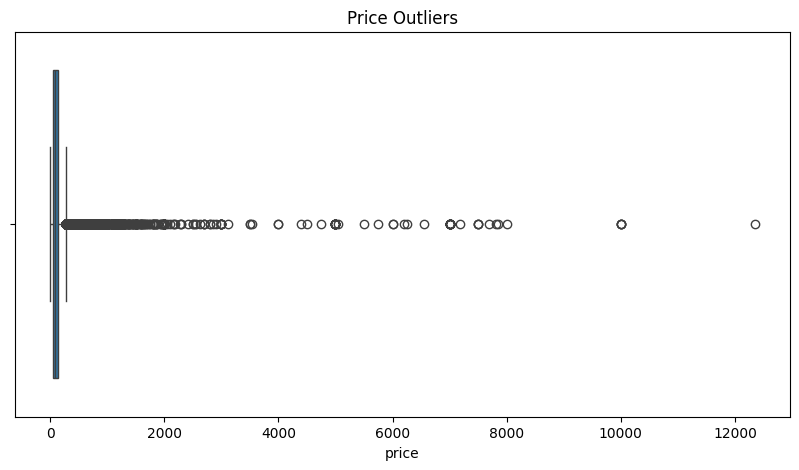

In [ ]:
df["price"] = df["price"].astype(str).str.replace('$', '').str.replace(',', '', regex=False)
# Convert 'price' column to numeric, coercing errors to NaN
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Drop NaN values from price column for IQR calculation and plotting
price_clean = df["price"].dropna()

# Detect Outliers Using IQR
Q1 = price_clean.quantile(0.25)
Q3 = price_clean.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["price"] < lower) | (df["price"] > upper)]
print("Outliers :", len(outliers))

# Visualize
plt.figure(figsize=(10,5))
sns.boxplot(x=price_clean) # Use the cleaned price series
plt.title("Price Outliers")
plt.show()

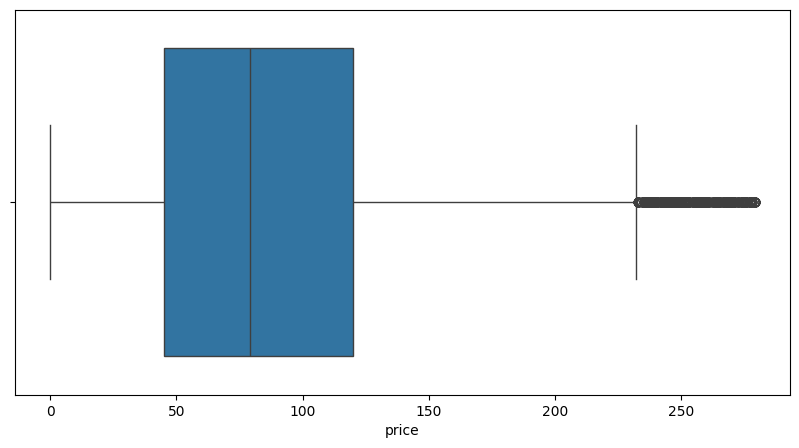

In [ ]:
 # Remove Outliers
df = df[(df["price"] >= lower) & (df["price"] <= upper)]

# Verify Outliers Again
plt.figure(figsize=(10,5))
sns.boxplot(x=df["price"])
plt.show()

In [ ]:
df["last_review"] = pd.to_datetime(
    df["last_review"],
    errors="coerce"
)

In [ ]:
# Cleaned Dataset
df.to_csv("cleaned_listings.csv", index=False)

In [ ]:
from google.colab import files
files.download("cleaned_listings.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#  2.Exploratory Data Analysis

In [ ]:
# Average Price Per Neighbourhood

average_price = (
    df.groupby("neighbourhood")["price"]
      .mean()
      .sort_values(ascending=False)
)

average_price.head(10)

,price
neighbourhood,
Unknown,200.000000
Mayfair,174.142857
St. James's,172.727273
Belgravia,171.613636
Covent Garden,162.530488
Soho,158.337500
Knightsbridge,155.940741
The West End,154.663265
City of London,145.456311


In [ ]:
# Most Popular Room Type
room_type = df["room_type"].value_counts()

room_type

,count
room_type,
Entire home/apt,42298
Private room,35572
Hotel room,926
Shared room,613


In [ ]:
#Top Hosts
top_hosts = (
    df.groupby(["host_id","host_name"])
      .size()
      .reset_index(name="Listings")
      .sort_values(by="Listings",ascending=False)
)
top_hosts.head(10)

,host_id,host_name,Listings
23028,33889201,Veeve,617
20924,28820321,Veronica,227
27992,48165024,William Hemming Associates Ltd,200
12990,13557337,Kindle Assets,172
1605,1432477,City Relay,157
28675,50291093,Mar,115
40088,137094377,Veeve,101
34509,83740964,Ali,101
40003,136223256,Alvaro,98
39971,135969957,Emran,89


# Professional hosts manage multiple listings, indicating commercial hosting activity.

In [ ]:
# Availability
df["availability_365"].describe()
bins=[0,90,180,270,365]

labels=["Low","Moderate","High","Very High"]
df["Availability_Category"]=pd.cut(
    df["availability_365"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
df["Availability_Category"].value_counts()

,count
Availability_Category,
Low,47879
Very High,17428
Moderate,9933
High,4169


In [ ]:
# Relationship Between Price and Reviews
df[["price","number_of_reviews"]].corr()


,price,number_of_reviews
price,1.000000,-0.097676
number_of_reviews,-0.097676,1.000000


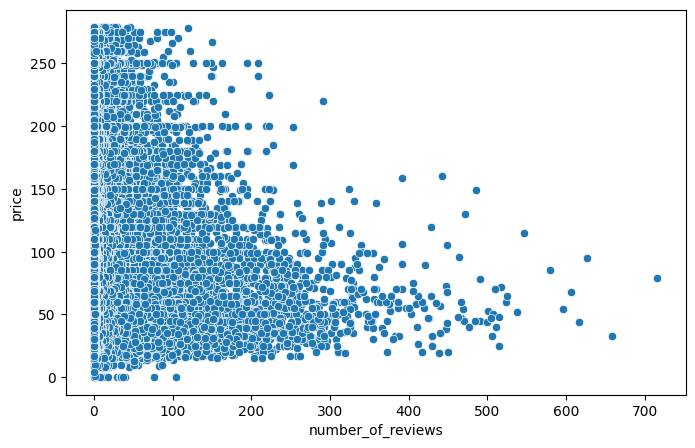

In [ ]:
# Scatter Plot
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="number_of_reviews",
    y="price"
)

plt.show()

# Price and number of reviews exhibit a weak relationship, indicating that expensive listings are not necessarily reviewed more often.

# 3.Visualization


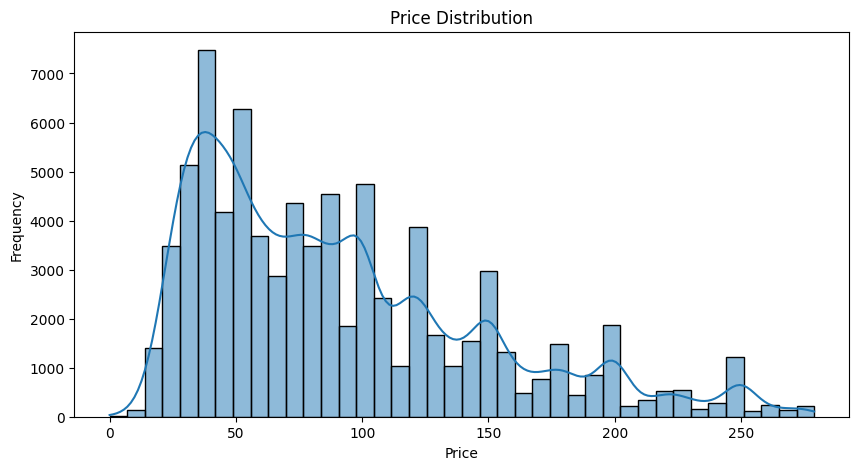

In [ ]:
# Price Distribution
plt.figure(figsize=(10,5))
sns.histplot(
    df["price"],
    bins=40,
    kde=True
)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

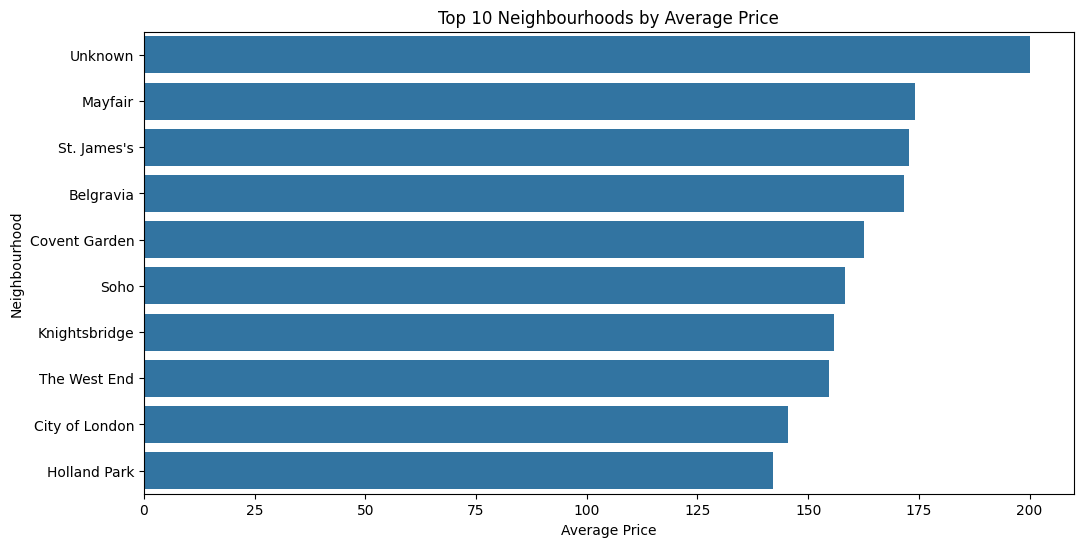

In [ ]:
#  Top 10 Neighbourhoods
top10 = (
    df.groupby("neighbourhood")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 Neighbourhoods by Average Price")
plt.xlabel("Average Price")
plt.ylabel("Neighbourhood")
plt.show()

# Average prices are significantly higher in central neighbourhoods, indicating that location strongly influences Airbnb pricing.

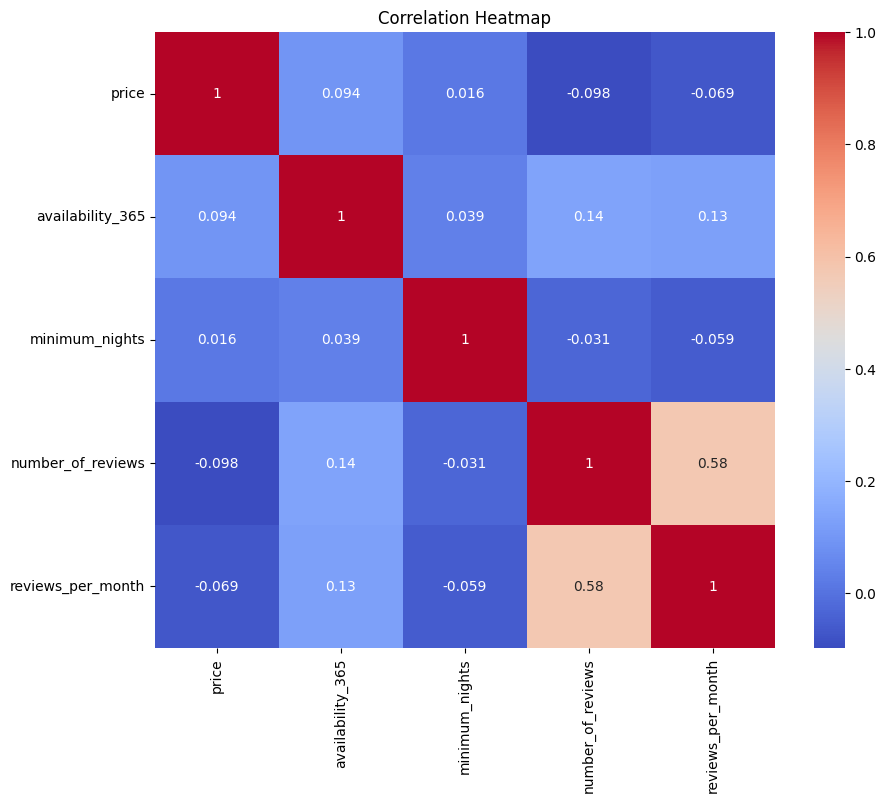

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,8))

corr=df[
[
"price",
"availability_365",
"minimum_nights",
"number_of_reviews",
"reviews_per_month"
]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Listings with moderate availability appear more common, suggesting balanced occupancy throughout the year.

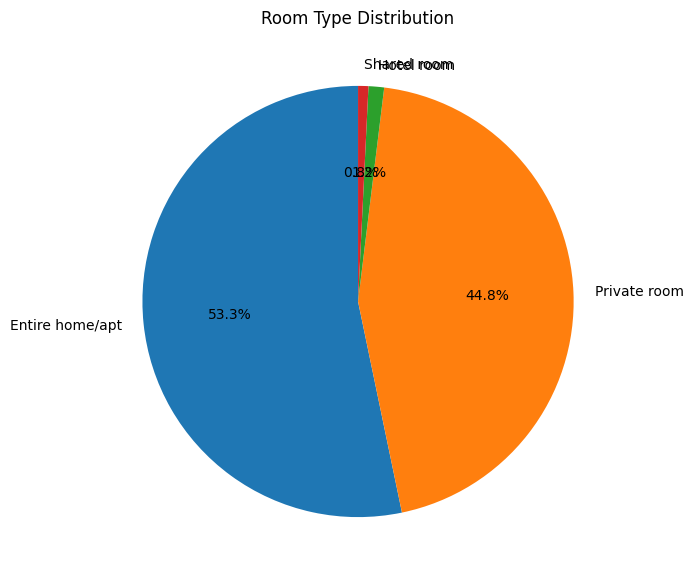

In [ ]:
# Room Type Pie Chart
room=df["room_type"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    room,
    labels=room.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Room Type Distribution")
plt.show()

# Entire homes are the most frequently listed room type, showing a preference among hosts to rent complete properties.

In [ ]:
!pip install folium

In [ ]:
# Geospatial Map
# Install:!pip install folium

import folium
airbnb_map=folium.Map(
    location=[
        df["latitude"].mean(),
        df["longitude"].mean()
    ],
    zoom_start=11
)

# Plot first 1000 listings
for _,row in df.head(1000).iterrows():
    folium.CircleMarker(
        location=[
            row["latitude"],
            row["longitude"]
        ],
        radius=2,
        popup=row["name"],
        fill=True
    ).add_to(airbnb_map)


In [ ]:
# Display
airbnb_map

# 4.Predictive Model

In [ ]:
# Predictive Model (Linear Regression & Random Forest)
#  Step 1:Import Machine Learning Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,r2_score)

In [ ]:
# Step 2: Select Features and Target
# For Airbnb price prediction, choose meaningful features.
# Independent Variables (Features)

X = df[
[
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count"
]
]

# Target Variable

y = df["price"]

In [ ]:
# Step 3: Check Missing Values
print(X.isnull().sum())
print(y.isnull().sum())

minimum_nights                    0
availability_365                  0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
dtype: int64
0


In [ ]:
# Step 4: Split Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Model 1: Linear Regression

In [ ]:
lr = LinearRegression()

In [ ]:
# Train the model.
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predict prices.
lr_prediction = lr.predict(X_test)

# Evaluate the model.
lr_mae = mean_absolute_error(y_test, lr_prediction)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_prediction))
lr_r2 = r2_score(y_test, lr_prediction)
print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE :", lr_rmse)
print("R2 Score :", lr_r2)

Linear Regression Results
MAE : 44.43958912812938
RMSE : 55.749193408193015
R2 Score : 0.06473770136386481


# Model 2: Random Forest

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
# Train model.
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Prediction.
rf_prediction = rf.predict(X_test)

# Evaluate.
rf_mae = mean_absolute_error(y_test, rf_prediction)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_prediction))
rf_r2 = r2_score(y_test, rf_prediction)
print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R2 Score :", rf_r2)

Random Forest Results
MAE : 40.739140783406754
RMSE : 53.0539460738322
R2 Score : 0.15298396034504935


# Compare Both Models

In [ ]:
comparison = {
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,44.439589,55.749193,0.064738
1,Random Forest,40.739141,53.053946,0.152984


# When comparing the models:
*   MAE (Mean Absolute Error): Lower is better.
*   RMSE (Root Mean Squared Error): Lower is better.
*   R² Score: Higher is better (closer to 1).










In [ ]:
# Determine the Better Model???
if rf_r2 > lr_r2:
    print("Random Forest performs better than Linear Regression.")
else:
    print("Linear Regression performs better than Random Forest.")

Random Forest performs better than Linear Regression.


In [ ]:
# Feature Importance (Random Forest Only)
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance



,Feature,Importance
3,reviews_per_month,0.253697
1,availability_365,0.251078
4,calculated_host_listings_count,0.216723
2,number_of_reviews,0.180392
0,minimum_nights,0.098110


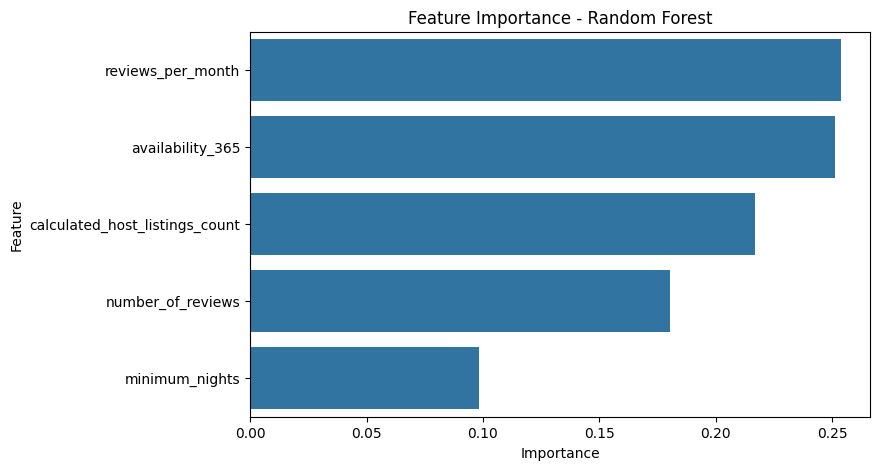

In [ ]:
# Plot Feature Importance
plt.figure(figsize=(8,5))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance - Random Forest")
plt.show()

# it can show which features contribute most to the predictions.......Random Forest

# 5.Sentiment Analysis

In [ ]:
reviews = pd.read_csv("reviews.csv", engine='python', on_bad_lines='skip')
reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,11551,30672,2010-03-21,93896,Shar-Lyn,"The flat was bright, comfortable and clean and..."
1,11551,32236,2010-03-29,97890,Zane,We stayed with Adriano and Valerio for a week ...
2,90700,337227,2011-06-27,311071,Miqua,it was all in all the perfect week!\r\nchilton...
3,90700,378738,2011-07-17,224367,Prateek,"I'll start with the host, and then move on to ..."
4,90700,543840,2011-09-18,1115024,Jennifer,Great location. Plenty to do just steps outsid...


In [ ]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1733260 entries, 0 to 1733259
Data columns (total 6 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   listing_id     object
 1   id             object
 2   date           object
 3   reviewer_id    object
 4   reviewer_name  object
 5   comments       object
dtypes: object(6)
memory usage: 79.3+ MB


In [ ]:
reviews.isnull().sum()

,0
listing_id,0
id,33
date,49
reviewer_id,64
reviewer_name,72
comments,760


In [ ]:
reviews = reviews.dropna(subset=["comments"])

In [ ]:
reviews.isnull().sum()

,0
listing_id,0
id,0
date,0
reviewer_id,0
reviewer_name,0
comments,0


In [ ]:
!pip install nltk

In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

In [ ]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
sia = SentimentIntensityAnalyzer()

In [ ]:
reviews["Sentiment_Score"] = reviews["comments"].astype(str).apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

In [ ]:
reviews[["comments", "Sentiment_Score"]].head()

,comments,Sentiment_Score
0,"The flat was bright, comfortable and clean and...",0.9413
1,We stayed with Adriano and Valerio for a week ...,0.9214
2,it was all in all the perfect week!\r\nchilton...,0.9827
3,"I'll start with the host, and then move on to ...",0.9974
4,Great location. Plenty to do just steps outsid...,0.9587


In [ ]:
# Create Sentiment Categories
def sentiment_category(score):
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

In [ ]:
# Apply the Function
reviews["Sentiment"] = reviews["Sentiment_Score"].apply(
    sentiment_category
)

In [ ]:
# View Results
reviews[
[
"comments",
"Sentiment_Score",
"Sentiment"
]
].head()

,comments,Sentiment_Score,Sentiment
0,"The flat was bright, comfortable and clean and...",0.9413,Positive
1,We stayed with Adriano and Valerio for a week ...,0.9214,Positive
2,it was all in all the perfect week!\r\nchilton...,0.9827,Positive
3,"I'll start with the host, and then move on to ...",0.9974,Positive
4,Great location. Plenty to do just steps outsid...,0.9587,Positive


In [ ]:
# Count Each Sentiment
reviews["Sentiment"].value_counts()

,count
Sentiment,
Positive,1491974
Neutral,167088
Negative,73438


In [ ]:
# Calculate Satisfaction Percentage
sentiment_percentage = (
    reviews["Sentiment"]
    .value_counts(normalize=True)
    *100
)

sentiment_percentage

,proportion
Sentiment,
Positive,86.116825
Neutral,9.644329
Negative,4.238846


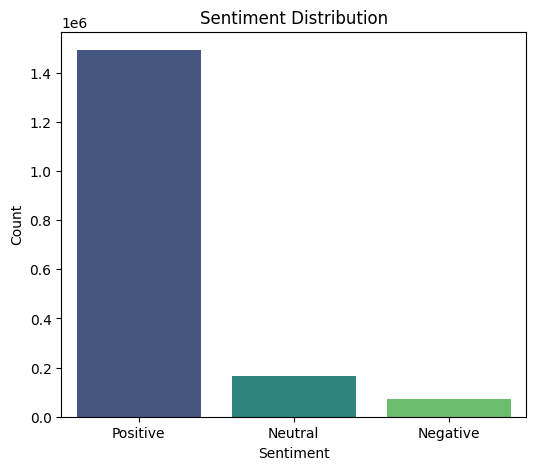

In [ ]:
# Plot a Bar Chart
plt.figure(figsize=(6,5))
sns.countplot(
    x="Sentiment",
    data=reviews,
    palette="viridis"
)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

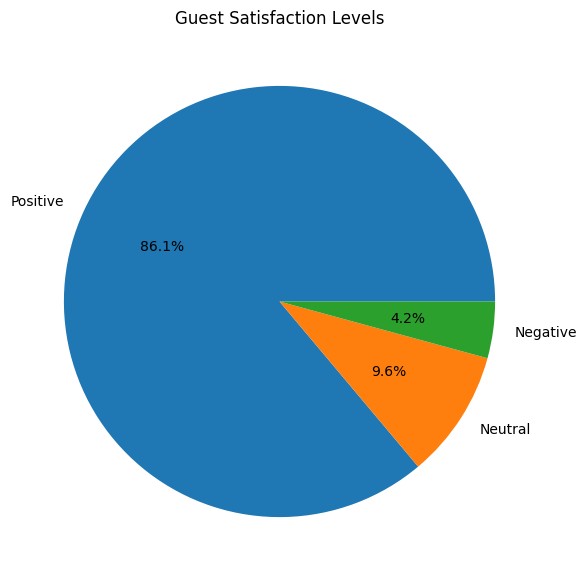

In [ ]:
# Pie Chart
reviews["Sentiment"].value_counts().plot(

kind="pie",

autopct="%1.1f%%",

figsize=(7,7)

)

plt.title("Guest Satisfaction Levels")

plt.ylabel("")

plt.show()

In [ ]:
# Display Sample Reviews
# Positive Reviews
reviews[
reviews["Sentiment"]=="Positive"
][
[
"comments",
"Sentiment_Score"
]
].head()

,comments,Sentiment_Score
0,"The flat was bright, comfortable and clean and...",0.9413
1,We stayed with Adriano and Valerio for a week ...,0.9214
2,it was all in all the perfect week!\r\nchilton...,0.9827
3,"I'll start with the host, and then move on to ...",0.9974
4,Great location. Plenty to do just steps outsid...,0.9587


In [ ]:
# Negative Reviews
reviews[
reviews["Sentiment"]=="Negative"
][
[
"comments",
"Sentiment_Score"
]
].head()

,comments,Sentiment_Score
24,Wonderfull host full stop.,-0.2960
117,J'ai passé quasi 6 jours chez Chilton avec ma ...,-0.1280
152,Nous avons passé trois nuits dans cet appartem...,-0.2003
172,We decided to book John's flat for 34 DAYS cau...,-0.6476
186,Jonh siempre fue muy amable resolvió nuestras ...,-0.5267


In [ ]:
# Save the Dataset
reviews.to_csv(
    "reviews_with_sentiment.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download("reviews_with_sentiment.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>